In [33]:
import sys
sys.path.append("../")
sys.path.append("../../variational-probcat/notebooks/")

import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange, repeat
import torch
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset, random_split
from pytorch_lightning.callbacks import LearningRateMonitor
import pytorch_lightning as pl
from tqdm_progress import TQDMProgressBar

from models.glow_module import GlowPL

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Download MNIST

In [6]:
from urllib import request
import gzip
import pickle

filename = [
["training_images","train-images-idx3-ubyte.gz"],
["test_images","t10k-images-idx3-ubyte.gz"],
["training_labels","train-labels-idx1-ubyte.gz"],
["test_labels","t10k-labels-idx1-ubyte.gz"]
]

def download_mnist():
    base_url = "http://yann.lecun.com/exdb/mnist/"
    for name in filename:
        print("Downloading "+name[1]+"...")
        request.urlretrieve(base_url+name[1], name[1])
    print("Download complete.")

def save_mnist():
    mnist = {}
    for name in filename[:2]:
        with gzip.open(name[1], 'rb') as f:
            mnist[name[0]] = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1,28*28)
    for name in filename[-2:]:
        with gzip.open(name[1], 'rb') as f:
            mnist[name[0]] = np.frombuffer(f.read(), np.uint8, offset=8)
    with open("mnist.pkl", 'wb') as f:
        pickle.dump(mnist,f)
    print("Save complete.")

def init():
    download_mnist()
    save_mnist()

def load():
    with open("mnist.pkl",'rb') as f:
        mnist = pickle.load(f)
    return mnist["training_images"], mnist["training_labels"], mnist["test_images"], mnist["test_labels"]

download_mnist()
save_mnist()

mnist_sq = rearrange(load()[0], 'b (h w) -> b h w', h=28)

Download complete.
Save complete.


In [19]:
x_train = torch.Tensor(mnist_sq)
theta_dummy = torch.zeros(mnist_sq.shape[0], 1)

In [21]:
batch_size = 128
val_fraction = 0.1

dataset = TensorDataset(x_train, theta_dummy)
n_samples_val = int(val_fraction * len(x_train))
dataset_train, dataset_val = random_split(dataset, [len(x_train) - n_samples_val, n_samples_val])
        
train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=2, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=2, pin_memory=True, shuffle=False)

/n/home11/smsharma/.local/lib/python3.8/site-packages/torch/utils/data/dataloader.py:487: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [34]:
model = GlowPL(num_levels=3)

In [35]:
max_epochs = 50

In [69]:
# Lightning callbacks
lr_monitor = LearningRateMonitor(logging_interval='epoch')
pgb = TQDMProgressBar(); pgb._val_processed = 10

# Instantiate trainer
trainer = pl.Trainer(max_epochs=max_epochs, gpus=1, gradient_clip_val=0.5, callbacks=[lr_monitor, pgb])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)  


In [45]:
def calc_z_shapes(n_channel=1, input_size=24, n_flow=18, n_block=3):
    z_shapes = []

    for i in range(n_block - 1):
        
        input_size //= 2
        n_channel *= 2

        z_shapes.append((n_channel, input_size, input_size))

    input_size //= 2
    z_shapes.append((n_channel * 4, input_size, input_size))

    return z_shapes

In [46]:
from tqdm import tqdm

In [47]:
model.to('cuda');

In [66]:
n_samples = 50

x_samples = []

for _ in tqdm(range(10)):
    z_sample = []
    z_shapes = calc_z_shapes()
    for z in z_shapes:
        z_new = torch.randn(n_samples, *z)
        z_sample.append(z_new.to('cuda'))

    x_samples_temp = (model.flow.reverse(z_sample, reconstruct=False, quant_int=False))
    x_samples.append(x_samples_temp)

100%|██████████| 10/10 [00:00<00:00, 20.06it/s]


In [67]:
x_samples = torch.cat(x_samples)
x_samples = x_samples.cpu()

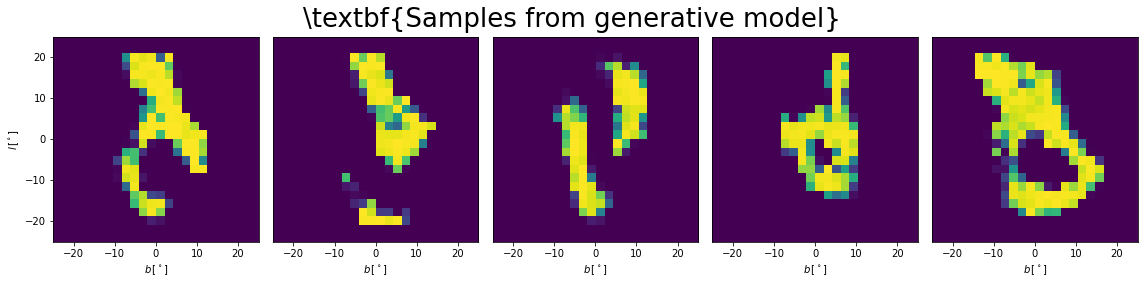

In [68]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy(), origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.set_xlabel(r"$b\,[^\circ]$")
    if i != 0:
        ax.set_xlabel(r"$b\,[^\circ]$")
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()
# plt.savefig("../paper/samples_gen.pdf")